In [1]:
import pandas as pd
import numpy as np

In [2]:
fraud_df = pd.read_csv("../data/raw/Fraud_data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [3]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
ip_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.geolocation import prepare_ip_df_bounds, map_ip_to_country

fraud_df['ip_int'] = fraud_df['ip_address'].astype('int64')

In [6]:
# Ensure IP range boundaries are integers and prepare ip_df
ip_df = prepare_ip_df_bounds(ip_df)

In [7]:
# Map ip integers to countries using the vectorized helper
fraud_df = map_ip_to_country(fraud_df, ip_df, ip_int_col='ip_int', country_col='country')

In [8]:
# Count total transactions per country
transaction_counts = fraud_df['country'].value_counts()
transaction_counts.head(20)

country
United States                      58049
Unknown                            21966
China                              12038
Japan                               7306
United Kingdom                      4490
Korea Republic of                   4162
Germany                             3646
France                              3161
Canada                              2975
Brazil                              2961
Italy                               1944
Australia                           1844
Netherlands                         1680
Russian Federation                  1616
India                               1310
Taiwan; Republic of China (ROC)     1237
Mexico                              1121
Sweden                              1090
Spain                               1027
South Africa                         838
Name: count, dtype: int64

In [9]:
# Analyze fraud rate by country
# ------------------------------------------------------------
# 'class' = 1 → fraudulent transaction
# Mean gives fraud rate per country

# Compute fraud rate per country
fraud_rate = fraud_df.groupby('country')['class'].mean().sort_values(ascending=False)
fraud_rate.head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

In [10]:
# Merge counts and fraud rate into a single DataFrame
country_summary = pd.DataFrame({
    'transactions': transaction_counts,
    'fraud_rate': fraud_rate
}).sort_values(by='fraud_rate', ascending=False)

country_summary.head(20)

,transactions,fraud_rate
country,,
Turkmenistan,1,1.000000
Namibia,23,0.434783
Sri Lanka,31,0.419355
Luxembourg,72,0.388889
Virgin Islands (U.S.),3,0.333333
Ecuador,106,0.264151
Tunisia,118,0.262712
Peru,119,0.260504
Bolivia,53,0.245283


C:\Users\dagic\AppData\Local\Temp\ipykernel_5128\2616115822.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='country', data=country_fraud, palette="flare_r", errwidth=0)
C:\Users\dagic\AppData\Local\Temp\ipykernel_5128\2616115822.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='class', y='country', data=country_fraud, palette="flare_r", errwidth=0)


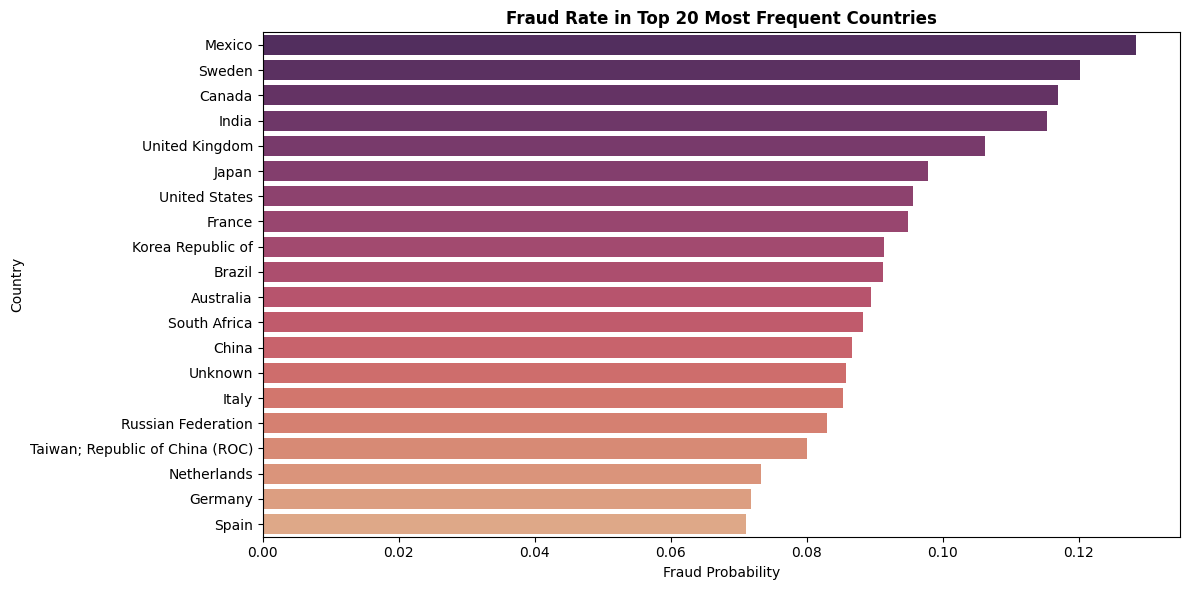

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot fraud rate for the top 20 most frequent countries
top_countries = fraud_df['country'].value_counts().head(20).index
country_fraud = (
    fraud_df[fraud_df['country'].isin(top_countries)]
    .groupby('country')['class'].mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(x='class', y='country', data=country_fraud, palette="flare_r", errwidth=0)
plt.title('Fraud Rate in Top 20 Most Frequent Countries', fontweight="bold")
plt.xlabel('Fraud Probability')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../notebooks/ecommerce_country_fraud.png', dpi=150, bbox_inches="tight")
plt.show()

C:\Users\dagic\AppData\Local\Temp\ipykernel_5128\2726274320.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='immediate_purchase', y='class', data=fraud_df, ax=axes[1], palette=["#4C72B0", "#DD4444"], errwidth=0)
C:\Users\dagic\AppData\Local\Temp\ipykernel_5128\2726274320.py:18: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='immediate_purchase', y='class', data=fraud_df, ax=axes[1], palette=["#4C72B0", "#DD4444"], errwidth=0)
C:\Users\dagic\AppData\Local\Temp\ipykernel_5128\2726274320.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Yes'])


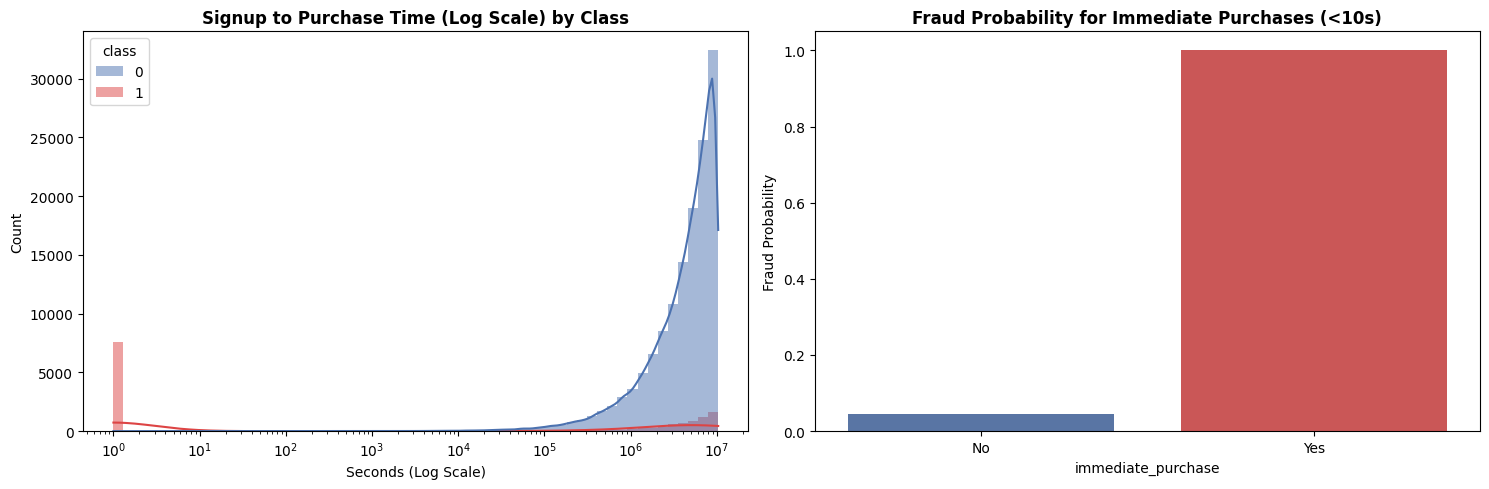

Immediate purchase counts: 7,600 transactions


In [12]:
# Ensure datetime columns exist before computing velocity
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# Calculate signup-to-purchase time (transaction velocity in seconds)
fraud_df['signup_to_purchase_time'] = (fraud_df['purchase_time'] - fraud_df['signup_time']).dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Log-scaled velocity distribution
sns.histplot(fraud_df, x='signup_to_purchase_time', hue='class', bins=60, kde=True,
             common_norm=False, log_scale=True, palette=["#4C72B0", "#DD4444"], ax=axes[0], edgecolor="none")
axes[0].set_title('Signup to Purchase Time (Log Scale) by Class', fontweight="bold")
axes[0].set_xlabel('Seconds (Log Scale)')

# Immediate purchase flag (under 10 seconds between signup & purchase)
fraud_df['immediate_purchase'] = (fraud_df['signup_to_purchase_time'] < 10).astype(int)
sns.barplot(x='immediate_purchase', y='class', data=fraud_df, ax=axes[1], palette=["#4C72B0", "#DD4444"], errwidth=0)
axes[1].set_title('Fraud Probability for Immediate Purchases (<10s)', fontweight="bold")
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()

print(f"Immediate purchase counts: {fraud_df['immediate_purchase'].sum():,} transactions")

C:\Users\dagic\AppData\Local\Temp\ipykernel_5128\387766603.py:11: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='device_sharing_count', y='class', data=fraud_df, ax=axes[0], color="#DD4444", errwidth=0)
C:\Users\dagic\AppData\Local\Temp\ipykernel_5128\387766603.py:17: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='ip_sharing_count', y='class', data=fraud_df, ax=axes[1], color="#DD4444", errwidth=0)


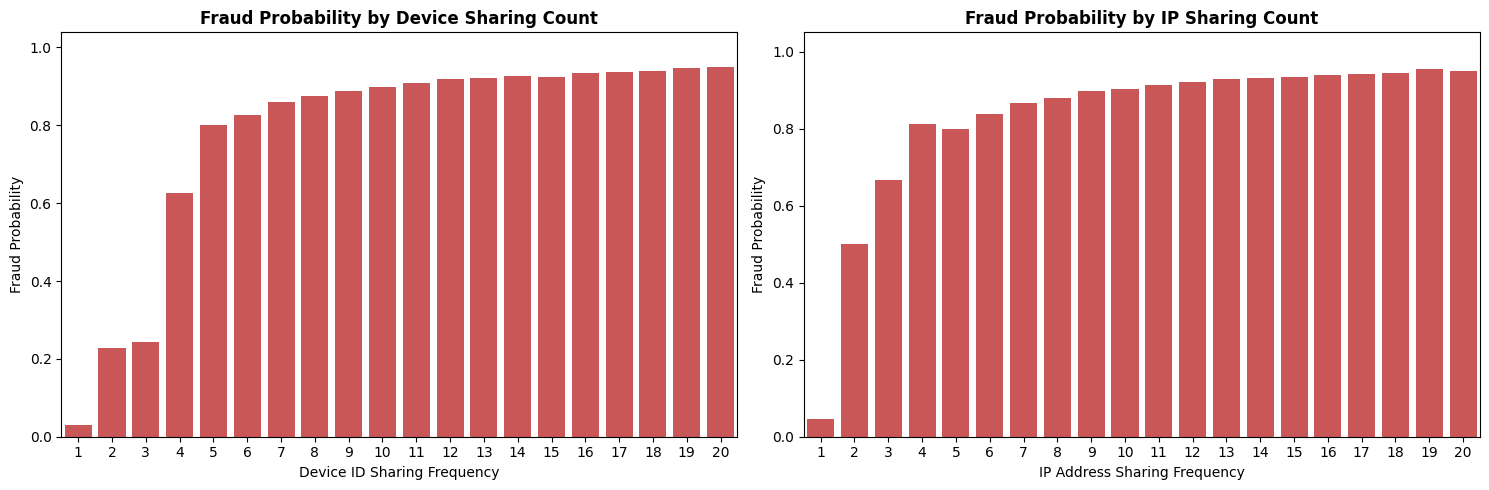

In [13]:
# Calculate sharing frequencies for device_id and ip_address
device_counts = fraud_df['device_id'].value_counts()
ip_counts = fraud_df['ip_address'].value_counts()

fraud_df['device_sharing_count'] = fraud_df['device_id'].map(device_counts)
fraud_df['ip_sharing_count'] = fraud_df['ip_address'].map(ip_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Device sharing count vs Class
sns.barplot(x='device_sharing_count', y='class', data=fraud_df, ax=axes[0], color="#DD4444", errwidth=0)
axes[0].set_title('Fraud Probability by Device Sharing Count', fontweight="bold")
axes[0].set_xlabel('Device ID Sharing Frequency')
axes[0].set_ylabel('Fraud Probability')

# IP sharing count vs Class
sns.barplot(x='ip_sharing_count', y='class', data=fraud_df, ax=axes[1], color="#DD4444", errwidth=0)
axes[1].set_title('Fraud Probability by IP Sharing Count', fontweight="bold")
axes[1].set_xlabel('IP Address Sharing Frequency')
axes[1].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()

## Insight:

    •	Device sharing: The risk remains relatively low (~25% or less) up to 3 users, but sky-rockets at 4+ shares (jumping above 60%) and hits an 80% risk baseline at 5 shares.
    •	Ip Address Sharing: A sharing frequency of just 2 users immediately spikes the fraud probability to 50%, and 3 users pushes it over 65%.


In [14]:
fraud_df.head(3)

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,country,signup_to_purchase_time,immediate_purchase,device_sharing_count,ip_sharing_count
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,732758368,Japan,4506682.0,0,1,1
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,350311387,United States,17944.0,0,1,1
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,2621473820,United States,1.0,1,12,12


In [15]:
from pathlib import Path
output = Path('../data/processed/fraud_mapped.csv')
output.parent.mkdir(parents=True, exist_ok=True)
fraud_df.to_csv(output, index=False)
print('saved to', output)

saved to ..\data\processed\fraud_mapped.csv
